# Slider Crank Mechanism Implementation

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
class SliderCrankJacobianSolver:
    def __init__(self, R1, R2, R4, theta1, theta2, theta3, angles_in_degrees=True):
        self.R1 = float(R1)
        self.R2 = float(R2)
        self.R4 = float(R4)

        if angles_in_degrees:
            self.theta1 = np.deg2rad(theta1)
            self.theta2 = np.deg2rad(theta2)
            self.theta3 = np.deg2rad(theta3)
            self.angles_in_degrees = True
        else:
            self.theta1 = float(theta1)
            self.theta2 = float(theta2)
            self.theta3 = float(theta3)
            self.angles_in_degrees = False

    def residual(self, x):
        R3, theta4 = x

        fx = (
            self.R1 * np.cos(self.theta1) - self.R2 * np.cos(self.theta2) + R3 * np.cos(self.theta3) + self.R4 * np.cos(theta4)
        )

        fy = (
            self.R1 * np.sin(self.theta1) - self.R2 * np.sin(self.theta2) + R3 * np.sin(self.theta3) + self.R4 * np.sin(theta4)
        )

        return np.array([fx, fy], dtype=float)

    def jacobian(self, x):
        _, theta4 = x

        return np.array(
            [
                [np.cos(self.theta3), -self.R4 * np.sin(theta4)],
                [np.sin(self.theta3), self.R4 * np.cos(theta4)],
            ],
            dtype=float,
        )

    def solve(self, R3_init, theta4_init, tol=1e-10, max_iter=50, return_history=False):
        theta4_init = np.deg2rad(theta4_init) if self.angles_in_degrees else float(theta4_init)
        x = np.array([float(R3_init), theta4_init], dtype=float)

        history = []

        for k in range(max_iter):
            F = self.residual(x)
            J = self.jacobian(x)

            try:
                delta = np.linalg.solve(J, -F)
            except np.linalg.LinAlgError:
                raise RuntimeError(f"Jacobian is singular at iteration: {k}. Try a different initial guess.")

            x = x + delta
            err = np.linalg.norm(delta, ord=2)
            history.append((k + 1, x.copy(), err, np.linalg.norm(F, ord=2)))

            if err < tol:
                result = {
                    "R3": x[0],
                    "theta4_rad": x[1],
                    "theta4_deg": np.rad2deg(x[1]),
                    "iterations": k + 1,
                    "converged": True,
                }
                if return_history:
                    result["history"] = history
                return result

        result = {
            "R3": x[0],
            "theta4_rad": x[1],
            "theta4_deg": np.rad2deg(x[1]),
            "iterations": max_iter,
            "converged": False,
        }
        if return_history:
            result["history"] = history
        return result

In [13]:
solver = SliderCrankJacobianSolver(
    R1=0.18, R2=0.12, R4=0.16,
    theta1=0.0, theta2=60.0, theta3=210.0,  # degrees
    angles_in_degrees=True
)

out = solver.solve(R3_init=0.20, theta4_init=120.0, tol=1e-12, max_iter=100, return_history=True)

Solution did not converge after 100 iterations
Final R3 = 0.107640 m
Final theta4 = -9534584094643700.00°


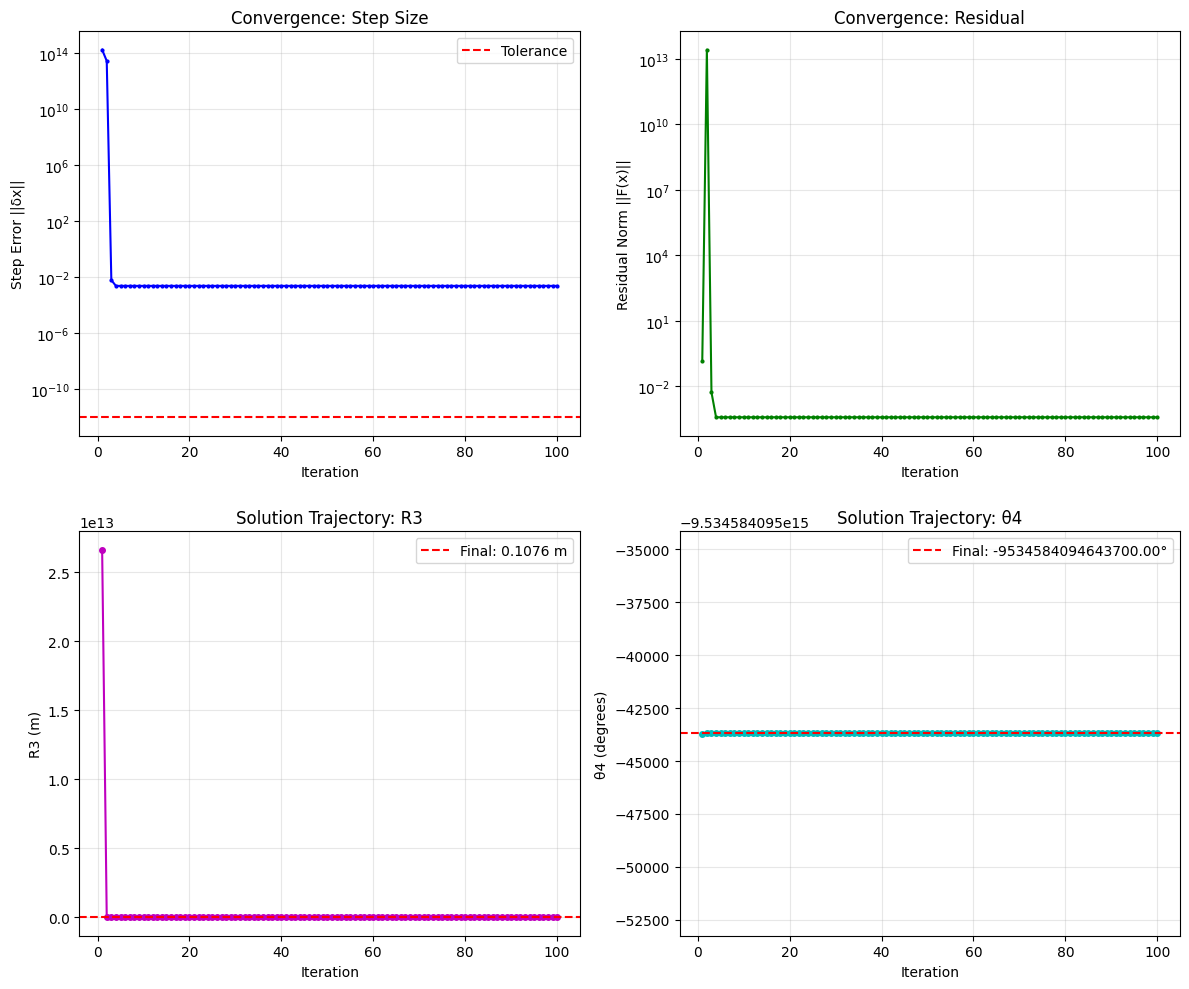

In [14]:
# Visualize convergence history
if out['converged']:
    print(f"Solution converged in {out['iterations']} iterations")
    print(f"R3 = {out['R3']:.6f} m")
    print(f"theta4 = {out['theta4_deg']:.2f}°")
else:
    print(f"Solution did not converge after {out['iterations']} iterations")
    print(f"Final R3 = {out['R3']:.6f} m")
    print(f"Final theta4 = {out['theta4_deg']:.2f}°")

# Extract history data
if 'history' in out:
    iterations = [h[0] for h in out['history']]
    R3_vals = [h[1][0] for h in out['history']]
    theta4_vals = [np.rad2deg(h[1][1]) for h in out['history']]
    step_errors = [h[2] for h in out['history']]
    residual_norms = [h[3] for h in out['history']]
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Plot 1: Step error (delta) convergence
    axes[0, 0].semilogy(iterations, step_errors, 'b.-', linewidth=1.5, markersize=4)
    axes[0, 0].axhline(y=1e-12, color='r', linestyle='--', label='Tolerance')
    axes[0, 0].set_xlabel('Iteration')
    axes[0, 0].set_ylabel('Step Error ||δx||')
    axes[0, 0].set_title('Convergence: Step Size')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    # Plot 2: Residual norm convergence
    axes[0, 1].semilogy(iterations, residual_norms, 'g.-', linewidth=1.5, markersize=4)
    axes[0, 1].set_xlabel('Iteration')
    axes[0, 1].set_ylabel('Residual Norm ||F(x)||')
    axes[0, 1].set_title('Convergence: Residual')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: R3 trajectory
    axes[1, 0].plot(iterations, R3_vals, 'mo-', linewidth=1.5, markersize=4)
    axes[1, 0].axhline(y=out['R3'], color='r', linestyle='--', label=f"Final: {out['R3']:.4f} m")
    axes[1, 0].set_xlabel('Iteration')
    axes[1, 0].set_ylabel('R3 (m)')
    axes[1, 0].set_title('Solution Trajectory: R3')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    # Plot 4: theta4 trajectory
    axes[1, 1].plot(iterations, theta4_vals, 'co-', linewidth=1.5, markersize=4)
    axes[1, 1].axhline(y=out['theta4_deg'], color='r', linestyle='--', label=f"Final: {out['theta4_deg']:.2f}°")
    axes[1, 1].set_xlabel('Iteration')
    axes[1, 1].set_ylabel('θ4 (degrees)')
    axes[1, 1].set_title('Solution Trajectory: θ4')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No history data available. Set return_history=True to visualize convergence.")